In [27]:
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [16]:
def covariance_to_correlation(covariance):
    D = np.diag(1 / np.sqrt(np.diag(covariance)))
    return D @ covariance @ D  # correlation matrix

In [13]:
prefix = "/gpfs/cfel/user/tjlane/mpro/mprodata/covariance/covariance_matrices/"

dataset_paths = {
    "DESY"    : prefix + "cov_xtal_ensemble.npy",
    "Diamond" : prefix + "cov_dmnd_ensemble.npy",
    "DESRES"  : prefix + "desres_sim.npy",
    "RIKEN"   : prefix + "riken_sim.npy",
    "Amaro"   : prefix + "amaro_sim.npy",
}

datasets = {}

In [14]:
for dataset_name, dataset_path in dataset_paths.items():
    dataset = np.load(dataset_path)
    if dataset_name in ["DESRES", "RIKEN", "Amaro"]:
        dataset = dataset[1:,1:]
    dataset = dataset[:301,:301]
    print(dataset_name, dataset.shape)
    datasets[dataset_name] = dataset

DESY (301, 301)
Diamond (301, 301)
DESRES (301, 301)
RIKEN (301, 301)
Amaro (301, 301)


In [18]:
distance_matrix = np.zeros([len(datasets),] * 2)

for i, (dataset1_name, dataset1) in enumerate(datasets.items()):
    for j, (dataset2_name, dataset2) in enumerate(datasets.items()):
        
        corr1 = covariance_to_correlation(dataset1)
        corr2 = covariance_to_correlation(dataset2)
        dist = np.linalg.norm(corr1 - corr2, ord="fro")

        distance_matrix[i,j] = dist
        
        print(dataset1_name, dataset2_name, dist)

DESY DESY 0.0
DESY Diamond 89.51562484298323
DESY DESRES 82.4546038130761
DESY RIKEN 104.42972523103268
DESY Amaro 145.90676463196087
Diamond DESY 89.51562484298323
Diamond Diamond 0.0
Diamond DESRES 60.09177694852988
Diamond RIKEN 77.10001035456084
Diamond Amaro 174.5784438816371
DESRES DESY 82.4546038130761
DESRES Diamond 60.09177694852988
DESRES DESRES 0.0
DESRES RIKEN 58.63927658666337
DESRES Amaro 157.59915016901473
RIKEN DESY 104.42972523103268
RIKEN Diamond 77.10001035456084
RIKEN DESRES 58.63927658666337
RIKEN RIKEN 0.0
RIKEN Amaro 160.20981736071224
Amaro DESY 145.90676463196087
Amaro Diamond 174.5784438816371
Amaro DESRES 157.59915016901473
Amaro RIKEN 160.20981736071224
Amaro Amaro 0.0


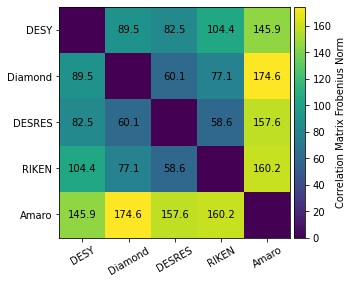

In [37]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(distance_matrix, cmap="viridis")

ax.set_xticks(np.arange(5))
ax.set_yticks(np.arange(5))
ax.set_xticklabels(datasets.keys(), rotation=30, ha="center")
ax.set_yticklabels(datasets.keys())

for i in range(distance_matrix.shape[0]):
    for j in range(distance_matrix.shape[1]):
        if i != j:
            ax.text(j, i, f"{distance_matrix[i, j]:.1f}", ha="center", va="center", color="black")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label("Correlation Matrix Frobenius Norm")

plt.tight_layout()
plt.savefig("./figures/correlation-matrix-frobenius-norm.pdf")
plt.show()